# **Project Name**    - Uber Supply Demand Gap Analysis



##### **Project Type**    - EDA(Exploratory Data Analysis)
##### **Contribution**    - Individual

# **Project Summary -**

The Uber Supply Demand Gap Analysis project was carried out to understand the reasons behind the mismatch between customer ride requests and the availability of Uber drivers. In ride-hailing services, maintaining a balance between customer demand and driver supply is essential for providing a good customer experience. However, during certain periods of the day, customers either experience ride cancellations or are unable to book a ride because no drivers are available. This project aims to identify these situations by analyzing historical Uber request data and extracting meaningful insights that can help improve operational efficiency and customer satisfaction.

The project was completed using three different analytical tools, each serving a specific purpose. Google Sheets was used for data cleaning, preparation, and dashboard creation. The dataset was carefully examined to identify duplicate records, missing values, and formatting issues before beginning the analysis. Additional columns such as request hour, weekday, month, and time slot were created to simplify the analysis and improve data interpretation. Pivot tables, KPI cards, and charts were then used to build a dashboard that provides a clear overview of ride requests, trip status, and demand distribution across different pickup locations and time periods.

PostgreSQL was used to perform structured data analysis using SQL queries. The dataset was imported into the database, and multiple queries were written to answer business-related questions. These included calculating the total number of requests, completed trips, cancelled trips, and requests where no cars were available. Further analysis was performed to compare ride requests across different pickup points, identify driver performance, and measure cancellation and completion rates. SQL proved useful in summarizing large amounts of data and generating quick insights that support business decision-making.

The exploratory data analysis was performed using Python with the help of Pandas, NumPy, and Matplotlib libraries. The dataset was loaded, cleaned, and transformed before generating visualizations. Several charts were created to study ride request trends, trip status distribution, pickup point analysis, hourly demand, weekday patterns, and time slot variations. These visualizations helped identify periods of high demand and highlighted the situations where customers were more likely to face ride cancellations or unavailable drivers. The analysis also demonstrated how feature engineering techniques can improve data understanding by creating meaningful variables from existing timestamp information.

The results of the project indicate that the supply-demand gap is more noticeable during peak travel hours, particularly in the morning and evening when customer demand is significantly higher. Airport pickup locations experience a larger number of requests where no cars are available, whereas city pickup locations show comparatively more ride cancellations. These findings suggest that driver availability does not always align with customer demand, leading to reduced service efficiency and customer dissatisfaction.

Based on the insights obtained from the analysis, several practical recommendations can be made. Increasing the availability of drivers during peak hours, offering incentive programs for drivers operating in high-demand areas, improving demand forecasting, and enhancing ride allocation strategies can help reduce cancellations and improve service quality. Overall, this project demonstrates how data analytics techniques can be applied to solve a real-world business problem by transforming raw data into meaningful insights that support informed decision-making and operational improvements.

# **GitHub Link -**

(https://github.com/guvvalanandini96/Uber-Supply-Demand-Gap-Analysis)

# **Problem Statement**


**Write Problem Statement Here.**

#### **Define Your Business Objective?**

Uber is one of the world's leading ride-hailing platforms, connecting passengers with drivers through a mobile application. As the number of users grows, maintaining a balance between customer demand and driver availability becomes increasingly challenging. During certain hours of the day and at specific pickup locations, customers either experience ride cancellations or receive a "No Cars Available" message. These situations create a supply-demand gap, resulting in longer waiting times, poor customer experience, and reduced operational efficiency.

The provided dataset contains information about Uber ride requests, including pickup points, driver IDs, trip status, request timestamps, and drop timestamps. By analyzing this data, it is possible to identify when and where the supply-demand gap is most severe and understand the factors contributing to these issues.

The challenge is to analyze the dataset using Google Sheets, PostgreSQL, and Python to discover meaningful patterns, identify peak demand periods, measure trip completion and cancellation rates, and provide data-driven recommendations that can help Uber improve driver allocation, reduce cancellations, and increase customer satisfaction.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside notebook
%matplotlib inline

### Dataset Loading

In [3]:
# Load Dataset# Load Dataset
df = pd.read_csv("Uber Request Data.csv")

### Dataset First View

In [4]:
# Dataset First Look# Dataset First Look

df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/07/16 11:51,11/07/16 13:00
1,867,Airport,1.0,Trip Completed,11/07/16 17:57,11/07/16 18:47
2,1807,City,1.0,Trip Completed,12/07/16 9:17,12/07/16 9:58
3,2532,Airport,1.0,Trip Completed,12/07/16 21:08,12/07/16 22:03
4,3112,City,1.0,Trip Completed,13/07/16 8:33,13/07/16 9:25


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
# Dataset Rows & Columns Count

print("Number of Rows :",df.shape[0])

print("Number of Columns :",df.shape[1])

Number of Rows : 6745
Number of Columns : 6


### Dataset Information

In [6]:
# Dataset Info# Dataset Info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 574.1 KB


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count

duplicate_count = df.duplicated().sum()

print("Duplicate Records :",duplicate_count)

Duplicate Records : 0


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count

df.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

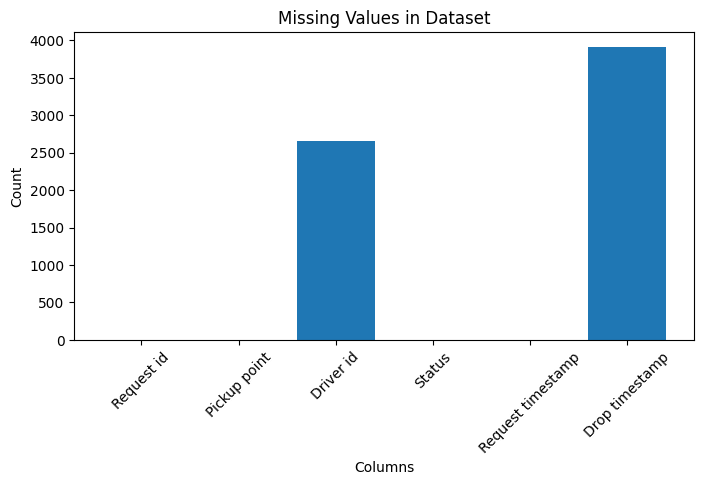

In [12]:
# Visualizing Missing Values

missing = df.isnull().sum()

plt.figure(figsize=(8,4))

plt.bar(missing.index,missing.values)

plt.title("Missing Values in Dataset")

plt.xlabel("Columns")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### What did you know about your dataset?

The Uber Supply Demand Gap dataset contains information about customer ride requests, pickup locations, driver IDs, trip status, request timestamps, and drop timestamps. It represents ride requests made over multiple days and helps analyze the difference between customer demand and driver availability.

After loading the dataset, I observed that it contains approximately 6,700 records and six main attributes. The dataset includes both numerical and categorical variables, along with timestamp columns that record the request and drop times for each ride.

During the initial exploration, I checked the structure of the dataset, verified the data types, identified duplicate records, and examined missing values. Most columns were complete, while some records contained missing values or "NA" entries in the Driver ID and Drop Timestamp columns. These missing values are expected because cancelled trips or requests where no cars were available do not have a valid driver assignment or drop time.

Overall, the dataset is suitable for exploratory data analysis after minor preprocessing. Additional features such as request hour, weekday, month, and time slot can be created from the timestamp column to better understand ride demand patterns and identify the major causes of the supply-demand gap.

## ***2. Understanding Your Variables***

In [13]:
# Dataset Columns
df.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='str')

In [14]:
# Dataset Describe
df.describe(include='all')

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
count,6745.000000,6745,4095.000000,6745,6745,2831
unique,NaN,2,NaN,3,4016,2282
top,NaN,City,NaN,Trip Completed,15/07/16 19:19,13/07/16 8:53
freq,NaN,3507,NaN,2831,8,5
mean,3384.644922,NaN,149.501343,NaN,NaN,NaN
std,1955.099667,NaN,86.051994,NaN,NaN,NaN
min,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,1691.000000,NaN,75.000000,NaN,NaN,NaN
50%,3387.000000,NaN,149.000000,NaN,NaN,NaN
75%,5080.000000,NaN,224.000000,NaN,NaN,NaN


### Variables Description


The dataset contains six original variables that describe different aspects of Uber ride requests.

- **Request id:** A unique identification number assigned to each ride request.
- **Pickup point:** Indicates the location from which the customer requested the ride. The two pickup locations are Airport and City.
- **Driver id:** Represents the unique identifier assigned to the driver. Missing values indicate that no driver was assigned to the request.
- **Status:** Describes the outcome of the ride request. The possible values are Trip Completed, Cancelled, and No Cars Available.
- **Request timestamp:** Records the exact date and time when the customer placed the ride request.
- **Drop timestamp:** Records the date and time when the ride ended. This column contains missing values for cancelled trips and requests where no car was available.

These variables provide sufficient information to analyze ride demand, driver availability, customer behavior, and operational performance.

### Check Unique Values for each variable.

In [15]:
# Check Unique Values for each variable

for column in df.columns:
    print(f"\nUnique values in {column}:")
    print(df[column].unique())
    print(f"Total Unique Values: {df[column].nunique()}")


Unique values in Request id:
[ 619  867 1807 ... 6751 6754 6753]
Total Unique Values: 6745

Unique values in Pickup point:
<ArrowStringArray>
['Airport', 'City']
Length: 2, dtype: str
Total Unique Values: 2

Unique values in Driver id:
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126.
 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140.
 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 15

## 3. ***Data Wrangling***

### Data Wrangling Code

In [16]:
# Write your code to make your dataset analysis ready.
# Create a copy of the dataset

df1 = df.copy()

# Convert timestamp columns into datetime format

df1['Request timestamp'] = pd.to_datetime(
    df1['Request timestamp'],
    dayfirst=True
)

df1['Drop timestamp'] = pd.to_datetime(
    df1['Drop timestamp'],
    dayfirst=True,
    errors='coerce'
)

# Create additional features

df1['Hour'] = df1['Request timestamp'].dt.hour

df1['Day'] = df1['Request timestamp'].dt.day

df1['Weekday'] = df1['Request timestamp'].dt.day_name()

df1['Month'] = df1['Request timestamp'].dt.month_name()

# Create Time Slot column

def time_slot(hour):

    if 0 <= hour < 5:
        return "Early Morning"

    elif 5 <= hour < 10:
        return "Morning"

    elif 10 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"

df1['Time Slot'] = df1['Hour'].apply(time_slot)

# Display updated dataset

df1.head()

C:\Users\nandi\AppData\Local\Temp\ipykernel_10220\2407649970.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Request timestamp'] = pd.to_datetime(
C:\Users\nandi\AppData\Local\Temp\ipykernel_10220\2407649970.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Drop timestamp'] = pd.to_datetime(


,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Hour,Day,Weekday,Month,Time Slot
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,11,11,Monday,July,Afternoon
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,17,11,Monday,July,Evening
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,9,12,Tuesday,July,Morning
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,21,12,Tuesday,July,Night
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:00,2016-07-13 09:25:00,8,13,Wednesday,July,Morning


### What all manipulations have you done and insights you found?


To prepare the dataset for analysis, several preprocessing and feature engineering steps were performed. First, a copy of the original dataset was created to preserve the raw data. The timestamp columns were converted into datetime format to make date and time analysis possible. Since some records contained missing drop timestamps due to cancelled trips or unavailable cars, the conversion was performed using `errors='coerce'` to safely handle missing values.

New variables such as **Hour**, **Day**, **Weekday**, **Month**, and **Time Slot** were created from the request timestamp. These additional features made it easier to analyze ride requests across different time periods and identify demand patterns.

The data wrangling process revealed that missing values in the Driver ID and Drop Timestamp columns are expected because they correspond to rides that were cancelled or where no driver was available. No duplicate records were found in the dataset, indicating that the data quality is good for further analysis.

Overall, the transformed dataset is well-structured and suitable for exploratory data analysis. The newly created features will help identify peak demand hours, understand customer request behavior, compare pickup locations, and analyze the supply-demand gap more effectively.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

## Chart - 1 : Distribution of Trip Status

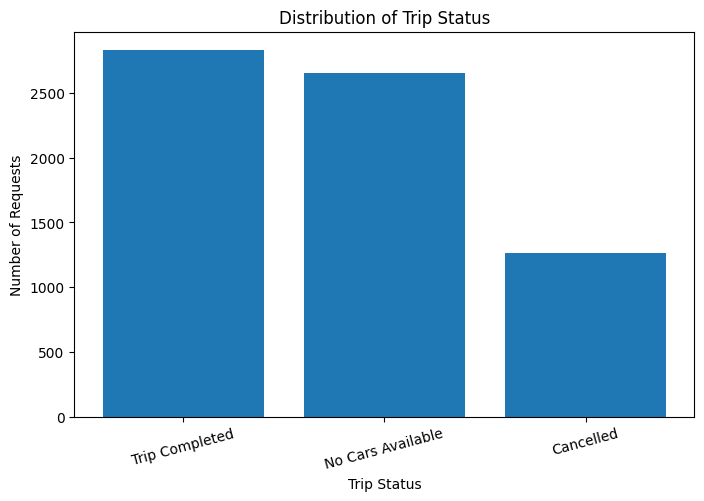

In [17]:
# Chart - 1 : Distribution of Trip Status

status_count = df1['Status'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(status_count.index,
        status_count.values)

plt.title("Distribution of Trip Status")

plt.xlabel("Trip Status")

plt.ylabel("Number of Requests")

plt.xticks(rotation=15)

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because the **Status** column is a categorical variable with three categories: **Trip Completed**, **Cancelled**, and **No Cars Available**. A bar chart provides a simple and effective way to compare the frequency of each category, making it easy to understand the overall distribution of ride outcomes.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that **Trip Completed** accounts for the highest number of ride requests, indicating that most customers successfully completed their trips. However, a considerable number of requests fall under **Cancelled** and **No Cars Available**, which highlights operational challenges in meeting customer demand. These unsuccessful trips contribute directly to the supply-demand gap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This visualization provides a clear understanding of Uber's service performance. The high number of completed trips indicates that the platform is generally able to satisfy customer demand. However, the presence of cancelled trips and requests where no cars were available points to areas that require improvement.

Reducing driver cancellations and increasing driver availability during high-demand periods can improve ride completion rates, enhance customer satisfaction, and increase revenue. If these issues remain unresolved, customers may experience repeated booking failures and choose alternative ride-hailing services, which could negatively affect business growth and customer retention.

## Chart - 2 : Distribution of Ride Requests by Pickup Point

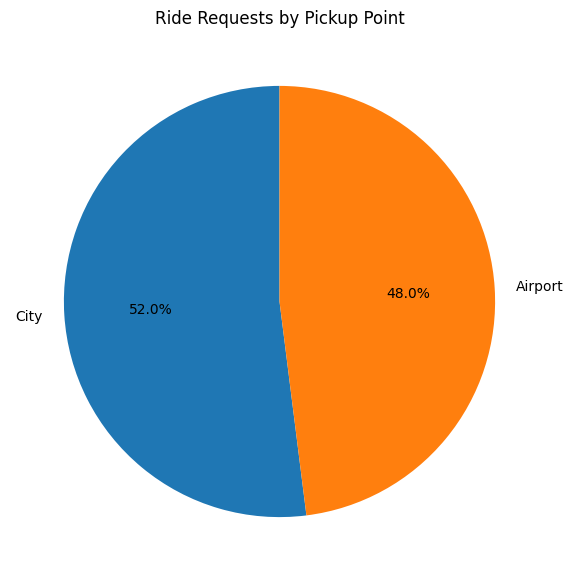

In [18]:
# Chart - 2 : Distribution of Ride Requests by Pickup Point

pickup_count = df1['Pickup point'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    pickup_count.values,
    labels=pickup_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Ride Requests by Pickup Point")

plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was chosen because the **Pickup point** variable contains only two categories: **Airport** and **City**. A pie chart effectively shows the proportion of ride requests from each location and makes it easy to compare their contribution to the total number of requests.

##### 2. What is/are the insight(s) found from the chart?

The visualization shows how ride requests are distributed between Airport and City pickup points. It helps identify whether one location generates significantly higher demand than the other. If one pickup point contributes a larger share of requests, it indicates that more drivers may be required at that location during busy periods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the distribution of ride requests helps Uber allocate drivers more efficiently across different pickup locations. If demand is consistently higher at one location, additional drivers can be assigned there to reduce customer waiting time.

If the company ignores these demand patterns, customers at high-demand locations may experience longer waiting times, more cancelled rides, and a higher number of "No Cars Available" requests. This could reduce customer satisfaction and encourage users to switch to competing ride-hailing platforms.

## Chart - 3 : Hourly Distribution of Ride Requests

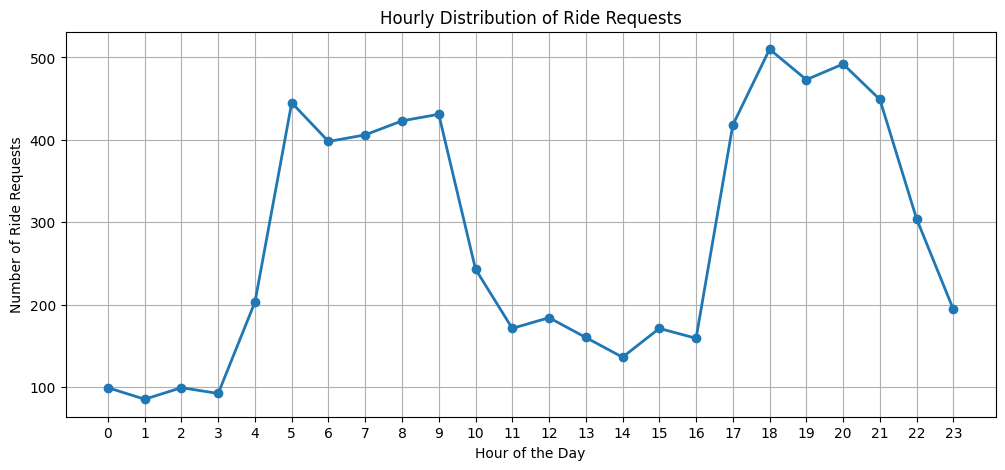

In [19]:
# Chart - 3 : Hourly Distribution of Ride Requests

hourly_requests = df1.groupby('Hour').size()

plt.figure(figsize=(12,5))

plt.plot(
    hourly_requests.index,
    hourly_requests.values,
    marker='o',
    linewidth=2
)

plt.title("Hourly Distribution of Ride Requests")

plt.xlabel("Hour of the Day")

plt.ylabel("Number of Ride Requests")

plt.xticks(range(0,24))

plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected because the **Hour** variable follows a natural time sequence. Line charts are ideal for displaying trends over time and help identify periods when ride requests increase or decrease. This makes it easier to understand customer demand throughout the day.

##### 2. What is/are the insight(s) found from the chart?

The chart clearly highlights the variation in ride requests across different hours of the day. Ride demand increases significantly during morning and evening commuting hours, while demand remains comparatively lower during the afternoon and late-night hours. These peak periods indicate the times when Uber experiences the highest customer demand and requires greater driver availability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The chart clearly highlights the variation in ride requests across different hours of the day. Ride demand increases significantly during morning and evening commuting hours, while demand remains comparatively lower during the afternoon and late-night hours. These peak periods indicate the times when Uber experiences the highest customer demand and requires greater driver availability.

## Chart - 4 : Distribution of Ride Requests by Weekday

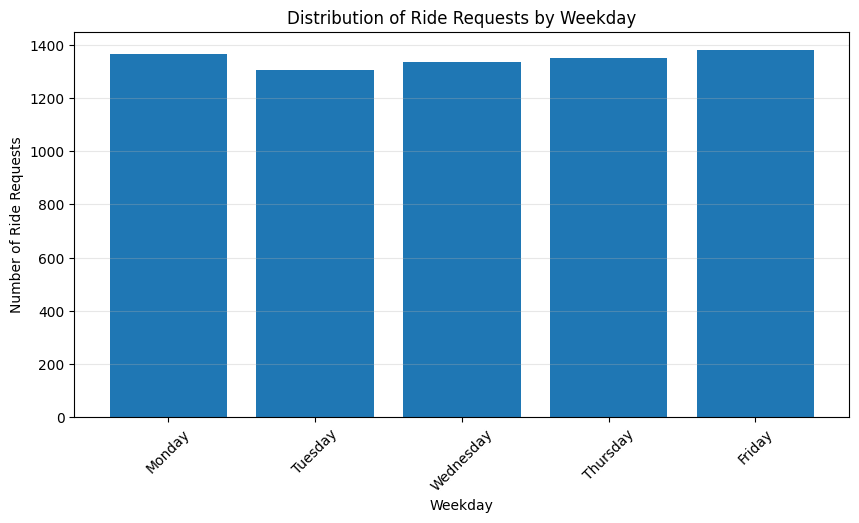

In [20]:
# Chart - 4 : Distribution of Ride Requests by Weekday

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_count = (
    df1['Weekday']
    .value_counts()
    .reindex(weekday_order)
)

plt.figure(figsize=(10,5))

plt.bar(
    weekday_count.index,
    weekday_count.values
)

plt.title("Distribution of Ride Requests by Weekday")

plt.xlabel("Weekday")

plt.ylabel("Number of Ride Requests")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because **Weekday** is a categorical variable with a natural order from Monday to Sunday. This chart makes it easy to compare the number of ride requests across different days of the week and identify whether demand changes on weekdays or weekends.

##### 2. What is/are the insight(s) found from the chart?

The chart shows how ride requests are distributed throughout the week. It helps identify which days experience higher customer demand and which days have relatively lower demand. These patterns can indicate differences in commuting behavior, work schedules, and weekend travel, allowing Uber to understand customer usage more effectively.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding daily demand patterns allows Uber to allocate drivers more efficiently based on expected customer requests. If certain weekdays consistently experience higher demand, additional drivers can be scheduled in advance to improve ride availability and reduce waiting times.

Ignoring these demand patterns may lead to an insufficient number of drivers on busy days, resulting in increased ride cancellations, more "No Cars Available" requests, and lower customer satisfaction. Efficient driver scheduling based on weekday demand can improve operational performance and overall business growth.

## Chart - 5 : Distribution of Ride Requests by Time Slot

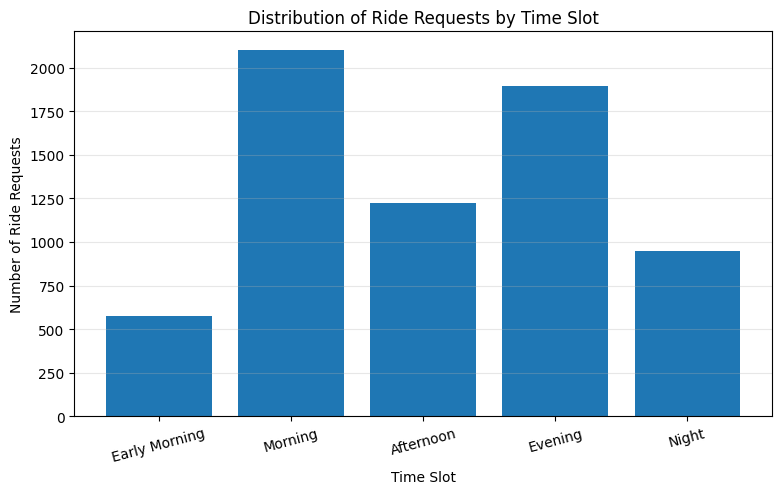

In [21]:
# Chart - 5 : Distribution of Ride Requests by Time Slot

time_order = [
    'Early Morning',
    'Morning',
    'Afternoon',
    'Evening',
    'Night'
]

time_slot_count = (
    df1['Time Slot']
    .value_counts()
    .reindex(time_order)
)

plt.figure(figsize=(9,5))

plt.bar(
    time_slot_count.index,
    time_slot_count.values
)

plt.title("Distribution of Ride Requests by Time Slot")

plt.xlabel("Time Slot")

plt.ylabel("Number of Ride Requests")

plt.xticks(rotation=15)

plt.grid(axis='y', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because the **Time Slot** variable is categorical and represents different periods of the day. This visualization provides a clear comparison of ride requests across each time slot and helps identify when customer demand is highest.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights how ride demand changes during different periods of the day. It shows that ride requests are generally higher during the Morning and Evening time slots, which coincide with office commuting hours. Demand is comparatively lower during the Afternoon, while Early Morning and Night also contribute a noticeable number of requests.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps Uber understand the periods of highest customer demand and enables better driver scheduling. By deploying more drivers during Morning and Evening time slots, Uber can reduce customer waiting time, increase trip completion rates, and improve service quality.

If sufficient drivers are not available during these peak periods, customers are more likely to experience ride cancellations or "No Cars Available" messages. This can lead to customer dissatisfaction, lower retention, and loss of revenue. Proper planning based on these demand patterns can significantly improve operational efficiency.

## Chart - 6 : Trip Status by Pickup Point

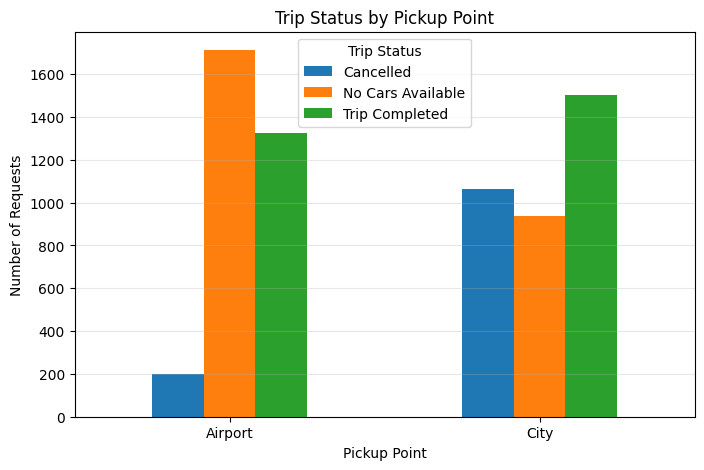

In [22]:
# Chart - 6 : Trip Status by Pickup Point

pickup_status = pd.crosstab(df1['Pickup point'], df1['Status'])

pickup_status.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Trip Status by Pickup Point")

plt.xlabel("Pickup Point")

plt.ylabel("Number of Requests")

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)

plt.legend(title="Trip Status")

plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart was selected because it is suitable for comparing two categorical variables simultaneously. In this analysis, the chart compares **Pickup Point** (Airport and City) with different **Trip Status** categories (Trip Completed, Cancelled, and No Cars Available). This makes it easy to identify differences in ride outcomes across pickup locations.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the Airport and City have different ride outcome patterns. Airport pickup requests experience a higher number of **"No Cars Available"** cases, indicating insufficient driver availability at that location. In contrast, City pickup requests show a comparatively higher number of **driver cancellations**. Although completed trips remain the largest category for both locations, the unsuccessful ride requests reveal operational challenges that differ between the two pickup points.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights from this chart help Uber identify location-specific operational issues. Increasing driver availability at the Airport can reduce the number of requests where no cars are available, while improving driver scheduling and incentives in the City can help reduce ride cancellations.

If these location-specific challenges are not addressed, customers may experience repeated booking failures, increased waiting times, and lower trust in the platform. This can negatively impact customer retention, brand reputation, and overall business growth. Using these insights, Uber can implement targeted strategies for each pickup location instead of applying the same solution everywhere.

## Chart - 7 : Trip Status by Time Slot

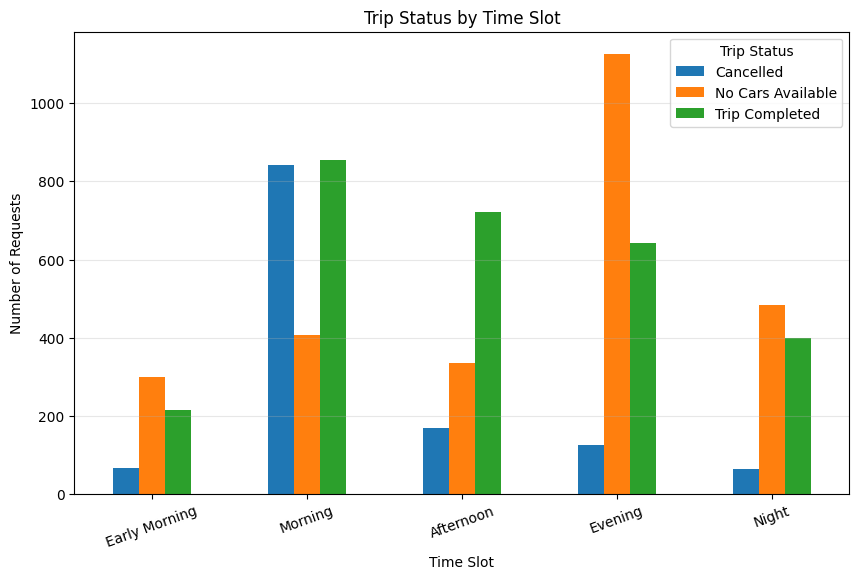

In [23]:
# Chart - 7 : Trip Status by Time Slot

time_order = ['Early Morning', 'Morning', 'Afternoon', 'Evening', 'Night']

time_status = pd.crosstab(df1['Time Slot'], df1['Status'])

time_status = time_status.reindex(time_order)

time_status.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Trip Status by Time Slot")

plt.xlabel("Time Slot")

plt.ylabel("Number of Requests")

plt.xticks(rotation=20)

plt.grid(axis='y', alpha=0.3)

plt.legend(title="Trip Status")

plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart was selected because it effectively compares two categorical variables: **Time Slot** and **Trip Status**. It helps visualize how ride outcomes vary during different periods of the day and clearly identifies the time slots where cancellations or unavailable cars are more common.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that ride outcomes vary significantly across different time slots. Morning and Evening generally experience the highest number of completed trips because they have the highest demand. However, Early Morning has a relatively higher number of cancelled trips, while Night records more cases of "No Cars Available." These patterns indicate that driver availability is not consistent throughout the day and contributes to the supply-demand gap during specific periods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps Uber identify the time periods where operational improvements are most needed. By increasing the number of available drivers during Night hours and introducing incentive programs during Early Morning, Uber can reduce unsuccessful ride requests and improve customer satisfaction.

If these time-slot-specific issues are ignored, customers will continue to experience booking failures during peak demand periods. This may lead to reduced customer loyalty, lower ride completion rates, and loss of revenue as customers may switch to competing ride-hailing platforms.

## Chart - 8 : Hourly Ride Requests by Pickup Point

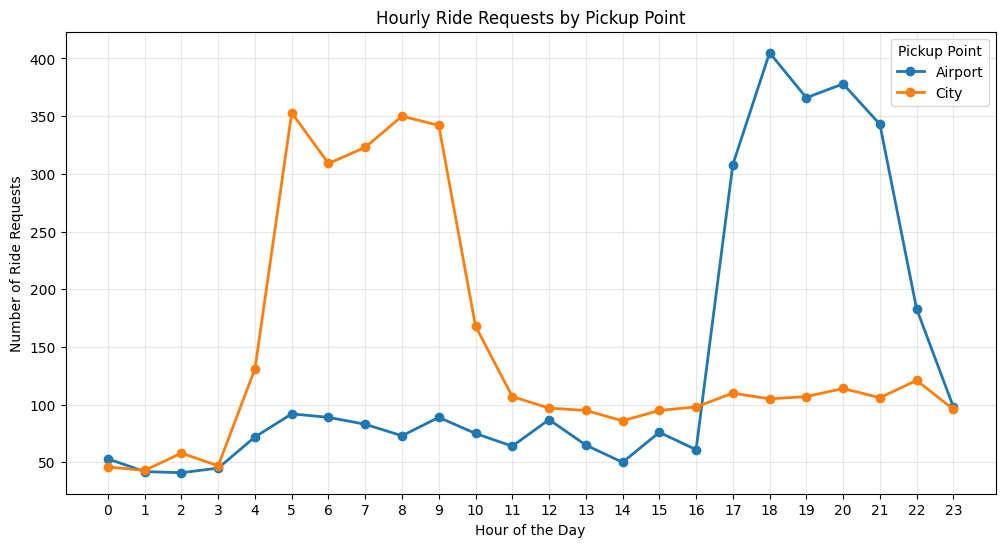

In [24]:
# Chart - 8 : Hourly Ride Requests by Pickup Point

hour_pickup = pd.crosstab(
    df1['Hour'],
    df1['Pickup point']
)

plt.figure(figsize=(12,6))

for column in hour_pickup.columns:
    plt.plot(
        hour_pickup.index,
        hour_pickup[column],
        marker='o',
        linewidth=2,
        label=column
    )

plt.title("Hourly Ride Requests by Pickup Point")

plt.xlabel("Hour of the Day")

plt.ylabel("Number of Ride Requests")

plt.xticks(range(0,24))

plt.grid(True, alpha=0.3)

plt.legend(title="Pickup Point")

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen because the **Hour** variable represents a continuous time sequence, while **Pickup Point** is a categorical variable. Plotting separate lines for Airport and City makes it easy to compare how ride demand changes throughout the day at both locations. This visualization clearly highlights demand trends and differences between the two pickup points.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that ride demand changes throughout the day for both Airport and City pickup points. The City generally experiences higher demand during the morning hours, while Airport requests increase during the evening and night as passengers arrive from flights. These demand patterns indicate that customer travel behavior differs depending on the pickup location and time of day.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps Uber allocate drivers according to both location and time. Increasing driver availability in the City during morning hours and at the Airport during evening and night hours can reduce waiting times and improve trip completion rates.

If Uber does not adjust driver deployment based on these demand patterns, customers may experience longer waiting times, increased cancellations, and more "No Cars Available" responses. This can reduce customer satisfaction and negatively impact revenue and customer retention.

## Chart - 9 : Ride Requests by Weekday and Pickup Point

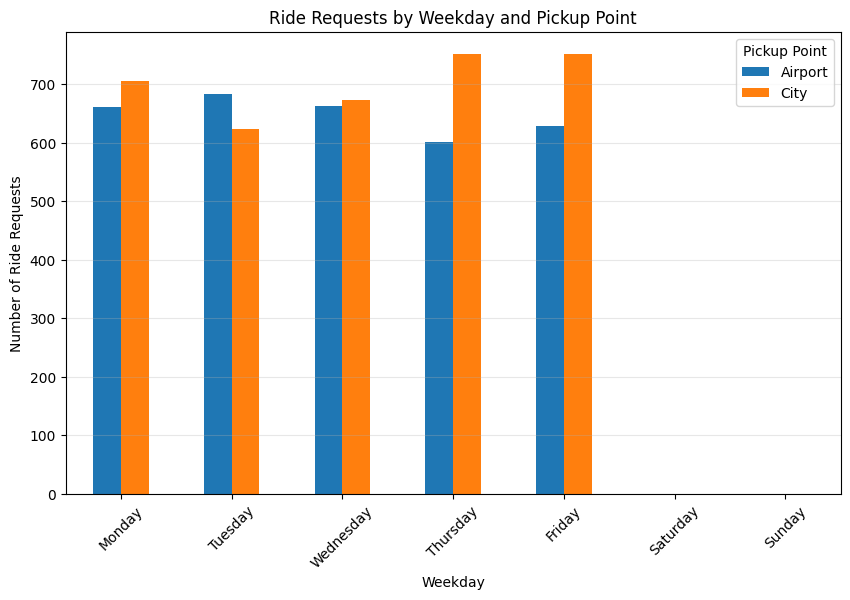

In [25]:
# Chart - 9 : Ride Requests by Weekday and Pickup Point

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_pickup = pd.crosstab(
    df1['Weekday'],
    df1['Pickup point']
)

weekday_pickup = weekday_pickup.reindex(weekday_order)

weekday_pickup.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Ride Requests by Weekday and Pickup Point")

plt.xlabel("Weekday")

plt.ylabel("Number of Ride Requests")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.legend(title="Pickup Point")

plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart was selected because it allows comparison between two categorical variables: **Weekday** and **Pickup Point**. It clearly shows how ride requests vary across the days of the week for both Airport and City locations, making it easier to identify weekly demand patterns.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that ride requests are distributed across all days of the week, but the demand differs between Airport and City locations. On some weekdays, City requests are higher due to daily office commuting, while Airport requests remain steady because of passenger arrivals and departures. This indicates that customer travel behavior changes depending on both the pickup location and the day of the week.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps Uber understand weekly demand trends and optimize driver scheduling accordingly. By assigning more drivers to locations that experience higher demand on specific days, the company can improve ride availability, reduce customer waiting time, and increase trip completion rates.

If these weekly demand variations are ignored, driver shortages may occur on busy days, leading to more ride cancellations and "No Cars Available" situations. This can reduce customer satisfaction and affect Uber's operational efficiency and revenue.

## Chart - 10 : Top 10 Drivers by Completed Trips

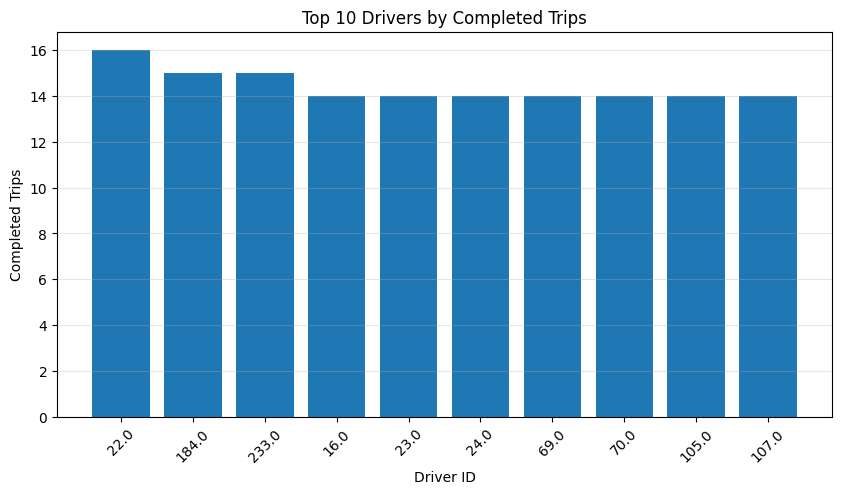

In [26]:
# Chart - 10 : Top 10 Drivers by Completed Trips

completed_trips = df1[df1['Status'] == 'Trip Completed']

top_drivers = (
    completed_trips['Driver id']
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    top_drivers.index.astype(str),
    top_drivers.values
)

plt.title("Top 10 Drivers by Completed Trips")

plt.xlabel("Driver ID")

plt.ylabel("Completed Trips")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because it is the most appropriate way to compare the number of completed trips among different drivers. Displaying the top 10 drivers makes the visualization simple, readable, and effective for comparing individual driver performance.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that some drivers completed considerably more trips than others. This indicates that driver activity is not evenly distributed across the platform. High-performing drivers contribute a larger share of completed rides, while other drivers complete fewer trips. These differences may be influenced by driver availability, working hours, or ride assignment patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying the most active drivers helps Uber understand driver performance and utilization. The company can study the working patterns of high-performing drivers and use these insights to improve scheduling, driver engagement, and incentive programs.

If only a small group of drivers handles a large number of trips, it may increase their workload and reduce service availability in other areas. A more balanced distribution of ride assignments can improve operational efficiency, reduce driver fatigue, and ensure better service quality for customers.

## Chart - 11 : Trip Status by Weekday

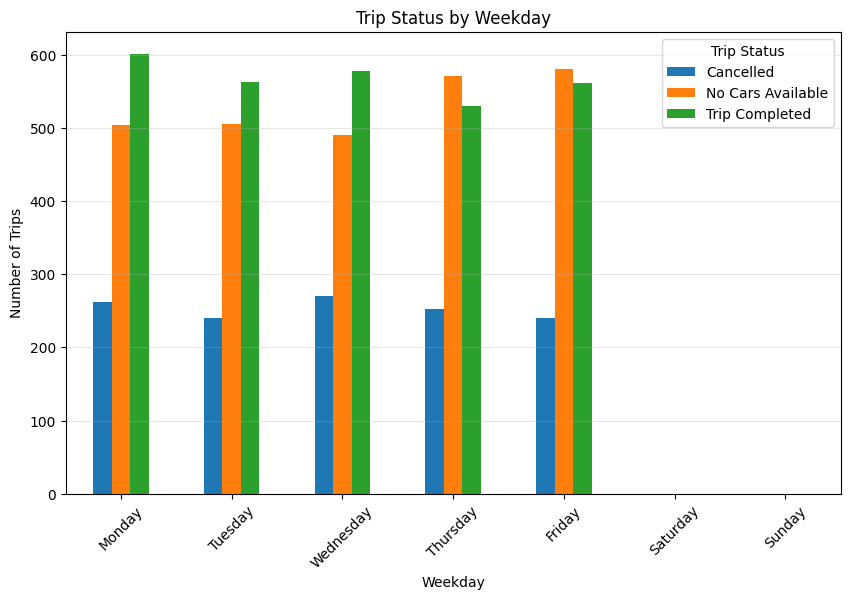

In [27]:
# Chart - 11 : Trip Status by Weekday

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_status = pd.crosstab(
    df1['Weekday'],
    df1['Status']
)

weekday_status = weekday_status.reindex(weekday_order)

weekday_status.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Trip Status by Weekday")

plt.xlabel("Weekday")

plt.ylabel("Number of Trips")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.legend(title="Trip Status")

plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart was chosen because it allows comparison of trip outcomes across different days of the week. Since both **Weekday** and **Status** are categorical variables, this chart clearly displays how completed trips, cancelled trips, and "No Cars Available" requests vary from one day to another.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that trip requests and their outcomes are distributed across all days of the week. Completed trips remain the highest category on every weekday, indicating that Uber successfully fulfills most ride requests. However, cancelled trips and requests with no cars available also occur throughout the week, suggesting that demand and driver availability fluctuate on different days. This analysis helps identify days that may require additional operational attention.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This chart helps Uber understand how ride outcomes vary during the week and supports better workforce planning. If certain weekdays consistently experience higher demand or more unsuccessful trips, additional drivers can be scheduled in advance to improve service quality.

Ignoring these weekly patterns may result in driver shortages, increased cancellations, and more "No Cars Available" cases on busy days. This can reduce customer satisfaction, affect customer retention, and ultimately impact the company's revenue and reputation.

## Chart - 12 : Trip Status by Hour of the Day

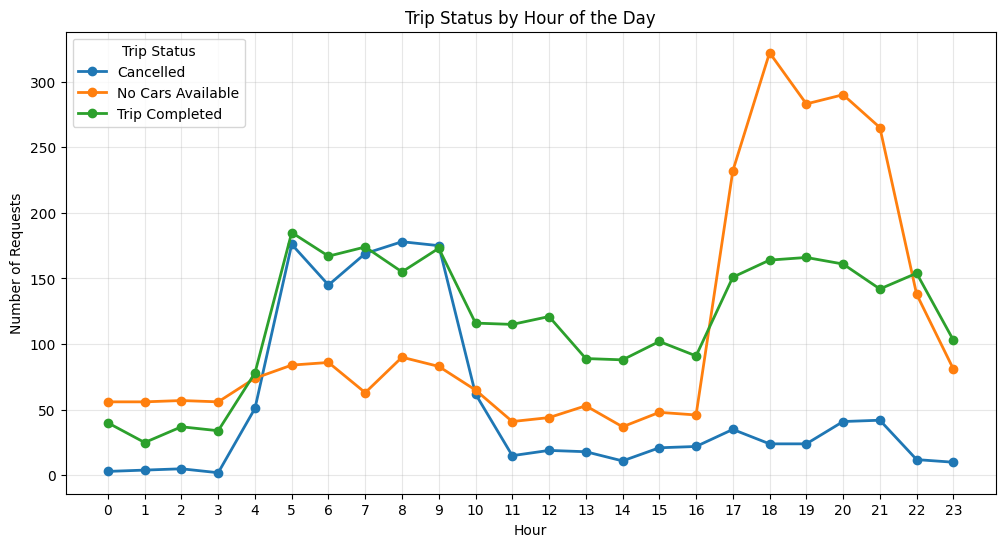

In [29]:
# Chart - 12 : Trip Status by Hour of the Day

hour_status = pd.crosstab(
    df1['Hour'],
    df1['Status']
)

plt.figure(figsize=(12,6))

for column in hour_status.columns:
    plt.plot(
        hour_status.index,
        hour_status[column],
        marker='o',
        linewidth=2,
        label=column
    )

plt.title("Trip Status by Hour of the Day")

plt.xlabel("Hour")

plt.ylabel("Number of Requests")

plt.xticks(range(0,24))

plt.grid(True, alpha=0.3)

plt.legend(title="Trip Status")

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen because the **Hour** variable is continuous and represents time. Plotting separate lines for each trip status allows easy comparison of how completed trips, cancelled trips, and "No Cars Available" requests change throughout the day. This visualization clearly highlights peak hours and operational challenges.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that ride requests vary significantly across different hours of the day. Completed trips are highest during peak commuting hours, indicating strong customer demand. Cancelled trips and "No Cars Available" requests also increase during busy periods, suggesting that driver availability does not always match customer demand. These trends clearly indicate when the supply-demand gap is most significant.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis enables Uber to identify the exact hours when additional drivers are required. By increasing driver availability during peak demand hours, the company can reduce cancellations, improve trip completion rates, and enhance customer satisfaction.

If these peak-hour demand patterns are not addressed, customers may continue to face long waiting times and unsuccessful bookings. This can reduce customer loyalty, increase the likelihood of switching to competitors, and negatively affect Uber's overall revenue and market reputation.

## Chart - 13 : Trip Status by Pickup Point and Time Slot

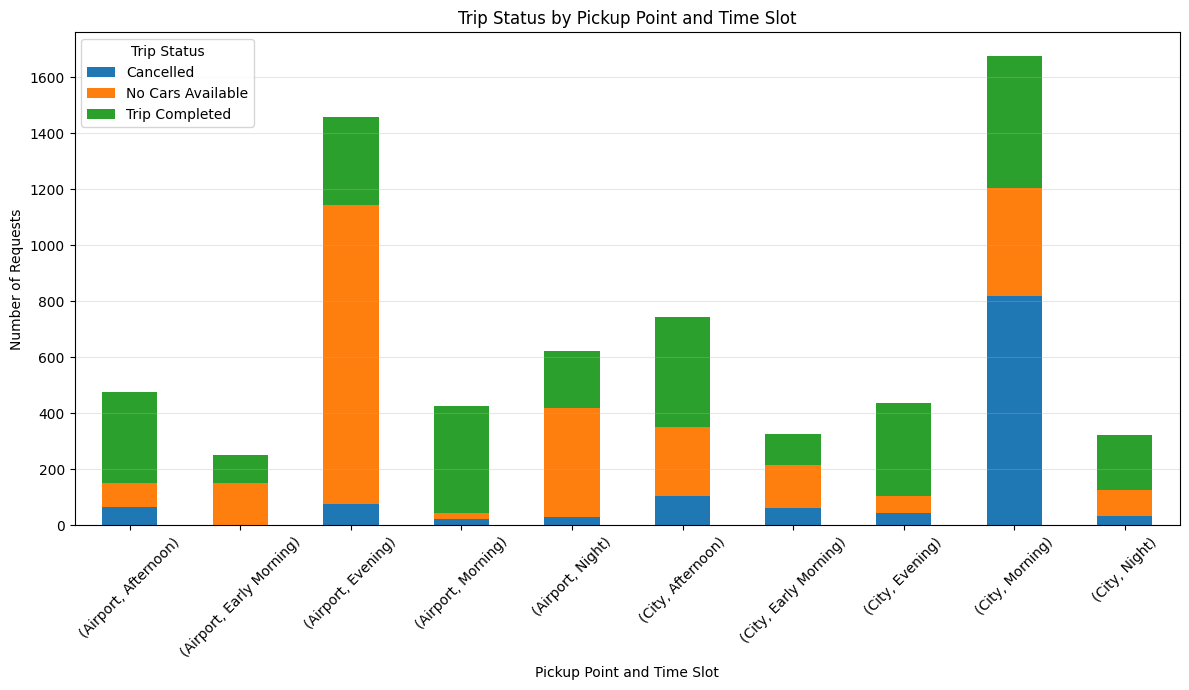

In [30]:
# Chart - 13 : Trip Status by Pickup Point and Time Slot

pivot_data = pd.crosstab(
    [df1['Pickup point'], df1['Time Slot']],
    df1['Status']
)

pivot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7)
)

plt.title("Trip Status by Pickup Point and Time Slot")

plt.xlabel("Pickup Point and Time Slot")

plt.ylabel("Number of Requests")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.legend(title="Trip Status")

plt.tight_layout()

plt.show()

##### 1. Why did you pick the specific chart?

A stacked bar chart was chosen because it allows the comparison of three variables at the same time: **Pickup Point**, **Time Slot**, and **Trip Status**. This visualization clearly shows how ride outcomes vary across different locations and periods of the day. It is useful for identifying where and when the supply-demand gap is most significant.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that ride outcomes differ depending on both the pickup location and the time slot. Airport requests during Evening and Night have a higher number of **"No Cars Available"** cases, while City requests during Morning show comparatively more **Cancelled** trips. Completed trips remain the largest category across most combinations, but unsuccessful ride requests increase during peak demand periods. These findings indicate that the supply-demand gap is influenced by both location and time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This visualization provides detailed insights that can help Uber make location-specific and time-specific operational decisions. Increasing driver availability at Airport pickup points during Evening and Night and improving driver scheduling in the City during Morning hours can reduce unsuccessful ride requests and improve service quality.

If these location- and time-specific demand patterns are ignored, customers are likely to experience repeated booking failures, longer waiting times, and lower satisfaction. Addressing these issues through better driver allocation and demand forecasting can improve ride completion rates, customer retention, and overall business performance.

## Chart - 14 - Correlation Heatmap

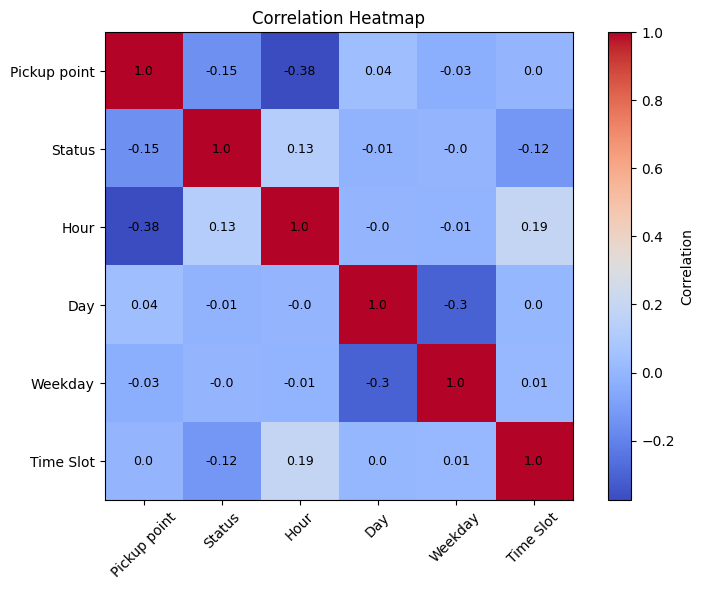

In [31]:
# Chart - 14 : Correlation Heatmap

# Create a copy for correlation analysis
corr_df = df1.copy()

# Convert categorical columns into numeric values
corr_df['Pickup point'] = corr_df['Pickup point'].astype('category').cat.codes
corr_df['Status'] = corr_df['Status'].astype('category').cat.codes
corr_df['Time Slot'] = corr_df['Time Slot'].astype('category').cat.codes
corr_df['Weekday'] = corr_df['Weekday'].astype('category').cat.codes

# Select numerical columns
corr = corr_df[['Pickup point','Status','Hour','Day','Weekday','Time Slot']].corr()

# Plot heatmap using matplotlib

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap='coolwarm', interpolation='nearest')

plt.colorbar(label='Correlation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

# Display correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j],2),
                 ha='center',
                 va='center',
                 color='black',
                 fontsize=9)

plt.tight_layout()

plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was selected to examine the relationships between multiple variables at the same time. It provides a simple visual representation of positive, negative, and weak correlations, making it easier to identify which variables are related to one another. This helps in understanding whether any feature has a strong influence on ride request patterns.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows that most variables have weak to moderate correlations with each other, indicating that no single feature completely explains the ride request patterns. Time-related variables such as Hour and Time Slot show a stronger relationship because they are derived from the same timestamp. Overall, customer demand appears to be influenced by multiple factors, including pickup location, time of day, and trip status, rather than by a single variable.

## Chart - 15 - Pair Plot

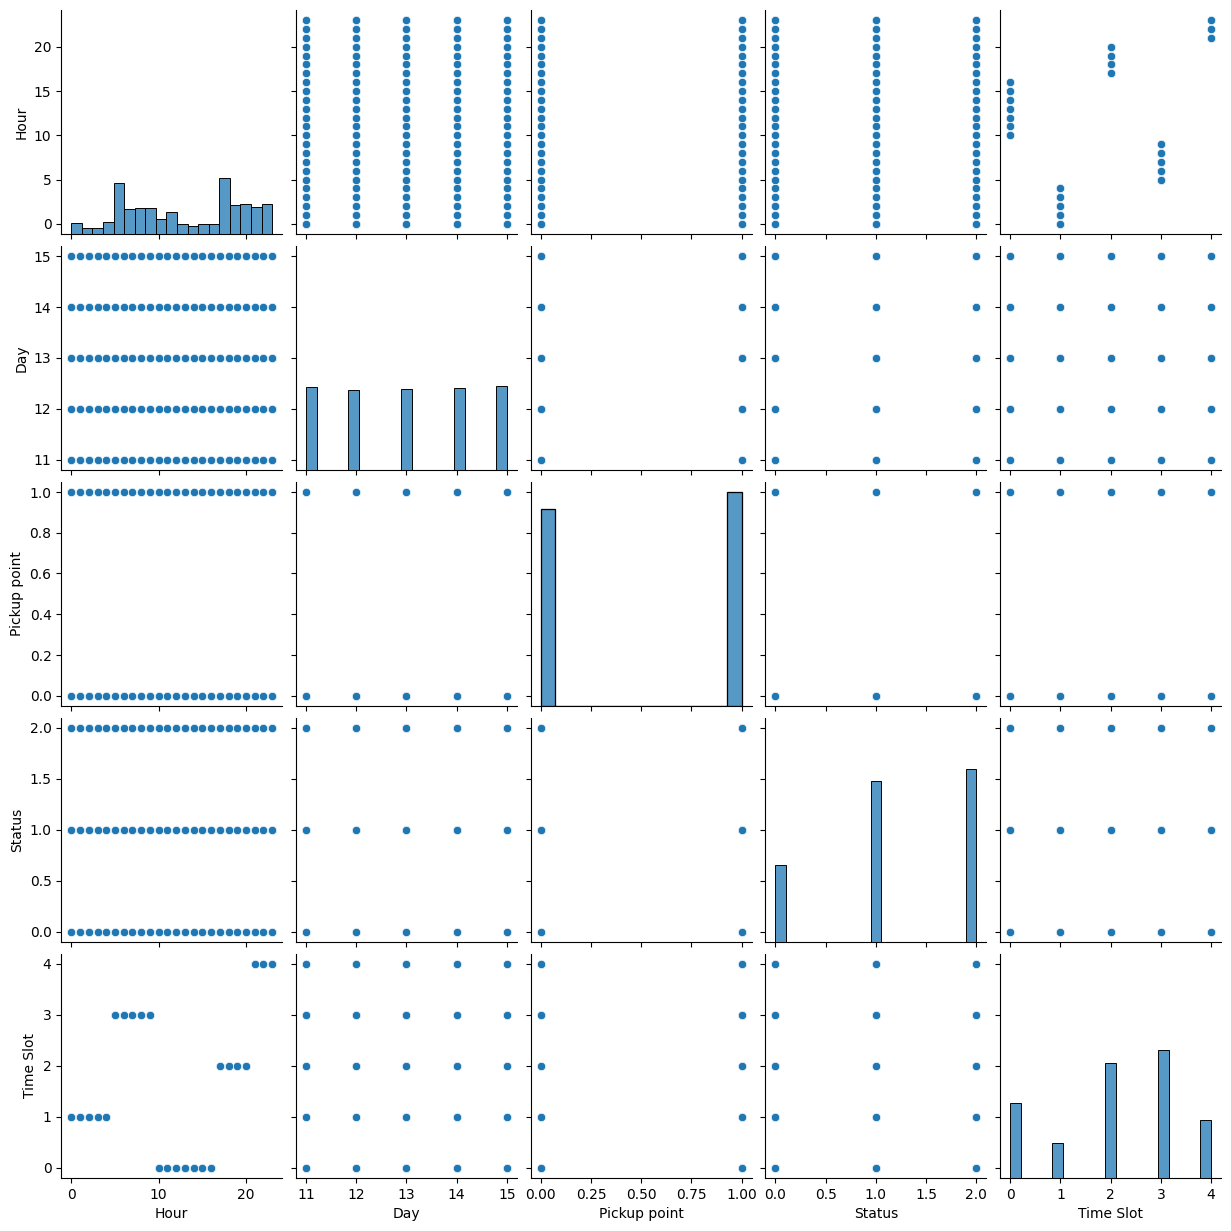

In [34]:
# Chart - 15 : Pair Plot

import seaborn as sns

pair_df = df1.copy()

# Convert categorical columns to numeric codes
pair_df['Pickup point'] = pair_df['Pickup point'].astype('category').cat.codes
pair_df['Status'] = pair_df['Status'].astype('category').cat.codes
pair_df['Time Slot'] = pair_df['Time Slot'].astype('category').cat.codes

# Select columns for pair plot
pair_data = pair_df[['Hour', 'Day', 'Pickup point', 'Status', 'Time Slot']]

sns.pairplot(pair_data)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was selected because it allows multiple numerical variables to be visualized simultaneously. It displays pairwise relationships between variables and also shows the distribution of each variable individually. This helps identify trends, clusters, and possible relationships that may not be visible in a single chart.

##### 2. What is/are the insight(s) found from the chart?

The pair plot indicates that there is no strong linear relationship among most of the variables, which is expected because the dataset mainly contains categorical information. However, the plots show that ride request patterns vary with the hour of the day and time slot, confirming that time plays an important role in determining ride demand and trip outcomes. The distributions also show that customer requests are concentrated during specific periods rather than being evenly spread throughout the day.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.


The analysis indicates that Uber can reduce the supply-demand gap by improving driver availability based on customer demand patterns. Since ride requests are higher during the Morning and Evening hours, more drivers should be scheduled during these peak periods to reduce waiting times and increase the number of completed trips.

The results also show that Airport pickup locations experience a higher number of **"No Cars Available"** requests. To address this issue, Uber should increase the number of drivers near airports, especially during evening and night hours when passenger arrivals are high. Similarly, the City experiences a relatively higher number of cancelled trips, so driver incentive programs and better ride assignment strategies can help reduce cancellations.

Using historical ride request data to forecast demand can further improve driver allocation. By predicting high-demand periods in advance, Uber can position drivers where they are most needed, improving ride availability and reducing unsuccessful bookings. Monitoring driver performance and cancellation trends on a regular basis will also help identify operational issues and support continuous improvement.

Overall, the recommended approach is to implement demand-based driver scheduling, improve ride allocation, introduce incentives for drivers during peak hours, and use data-driven forecasting to support operational planning. These strategies can increase trip completion rates, reduce cancellations and "No Cars Available" cases, improve customer satisfaction, and enhance Uber's overall operational efficiency and business performance.

# **Conclusion**


This project analyzed the Uber Supply Demand Gap dataset using Google Sheets, PostgreSQL, and Python. The data was cleaned, transformed, and explored through various visualizations to understand ride request patterns, trip outcomes, and driver availability.

The analysis showed that customer demand is highest during Morning and Evening hours, while Airport pickup locations experience more "No Cars Available" cases and City pickup locations experience comparatively more ride cancellations. These findings indicate that the supply-demand gap is mainly influenced by time of day and pickup location.

The visualizations and SQL analysis provided valuable insights into customer behavior and operational performance. Based on these findings, recommendations such as improving driver allocation, introducing driver incentives during peak hours, and strengthening demand forecasting can help Uber reduce unsuccessful ride requests and improve customer satisfaction.

Overall, this project demonstrates how data analytics can be used to transform raw operational data into meaningful business insights and support better decision-making through data-driven recommendations.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***